In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Generate synthetic data: y = 1 if x > 0 else 0
np.random.seed(0)
X = np.random.randn(100, 2)  # 100 data points, 2 features
y = (X[:, 0] + X[:, 1] > 0).astype(int)  # Target variable

In [3]:
np.random.seed(0)
X = np.random.randn(30, 2)  # 300 data points, 2 features

# Assign each point to a class based on the sum of the features
y = (X[:, 0] + X[:, 1] > 0).astype(int) + (X[:, 0] - X[:, 1] > 0).astype(
    int
) * 2  # 3 classes (0, 1, 2)

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)  # Use long tensor for integer class labels

In [4]:
y_tensor

tensor([3, 1, 3, 3, 1, 1, 3, 3, 3, 2, 0, 3, 3, 2, 3, 1, 2, 0, 3, 0, 2, 1, 0, 0,
        0, 0, 2, 1, 1, 0])

In [5]:
class MulticlassLogisticRegressionModel(nn.Module):
    def __init__(self, input_size, num_classes):
        super(MulticlassLogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(input_size, num_classes)  # One output per class

    def forward(self, x):
        return self.linear(
            x
        )  # No activation needed, softmax will be applied during loss computation

In [6]:
input_size = 2  # Two input features
num_classes = 4  # Three classes
model = MulticlassLogisticRegressionModel(input_size, num_classes)
criterion = nn.CrossEntropyLoss()  # Cross-Entropy loss for multiclass
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [7]:
epochs = 1000
for epoch in range(epochs):
    # Forward pass
    y_pred = model(X_tensor)

    # Compute the loss
    loss = criterion(y_pred, y_tensor)

    # Backward pass
    optimizer.zero_grad()  # Clear previous gradients
    loss.backward()  # Backpropagate the gradients
    optimizer.step()  # Update the weights

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [100/1000], Loss: 1.0013
Epoch [200/1000], Loss: 0.8788
Epoch [300/1000], Loss: 0.7947
Epoch [400/1000], Loss: 0.7334
Epoch [500/1000], Loss: 0.6867
Epoch [600/1000], Loss: 0.6497
Epoch [700/1000], Loss: 0.6194
Epoch [800/1000], Loss: 0.5940
Epoch [900/1000], Loss: 0.5723
Epoch [1000/1000], Loss: 0.5533


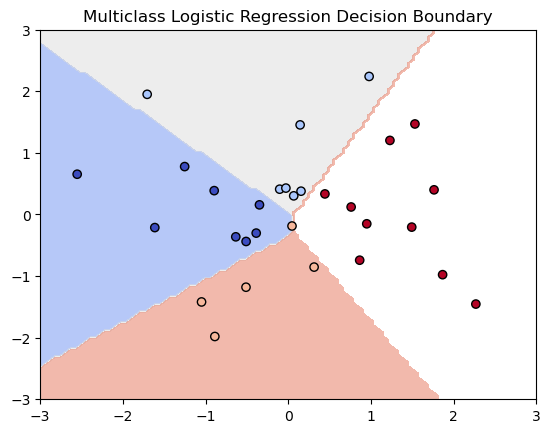

In [8]:
# Create a meshgrid for plotting decision boundaries
xx, yy = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-3, 3, 100))
grid_points = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
with torch.no_grad():
    z = model(grid_points)
    _, predicted_classes = torch.max(z, 1)
    z = predicted_classes.reshape(xx.shape)

# Plot decision boundaries
plt.contourf(
    xx, yy, z.numpy(), levels=np.arange(-0.5, 3, 1), cmap="coolwarm", alpha=0.5
)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k", marker="o")
plt.title("Multiclass Logistic Regression Decision Boundary")
plt.show()

In [9]:
import torch

t = torch.rand((30, 30))

torch.fft.fftn(t, dim=1).shape

torch.Size([30, 30])

In [10]:
import torch
import torch.optim as optim
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Generate synthetic dataset
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# Initialize weights and bias manually
input_dim = X_train.shape[1]
W = torch.randn(
    (input_dim, 1), dtype=torch.float32, requires_grad=True
)  # Weight matrix
b = torch.zeros(1, dtype=torch.float32, requires_grad=True)  # Bias

# Define optimizer
optimizer = optim.SGD([W, b], lr=0.1)


# Binary Cross Entropy Loss function
def binary_cross_entropy(y_pred, y_true):
    return -(y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred)).mean()


# Training loop
num_epochs = 100
for epoch in range(num_epochs):
    # Compute model output (manually applying linear function + sigmoid)
    logits = X_train_tensor @ W + b  # Linear transformation
    y_pred = torch.sigmoid(logits)  # Apply sigmoid activation

    # Compute loss
    loss = binary_cross_entropy(y_pred, y_train_tensor)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# Evaluate the model
with torch.no_grad():
    y_pred_test = torch.sigmoid(X_test_tensor @ W + b)
    y_pred_class = (y_pred_test >= 0.5).float()
    accuracy = (y_pred_class.eq(y_test_tensor)).sum() / float(y_test_tensor.shape[0])
    print(f"Accuracy: {accuracy.item():.4f}")

Epoch [10/100], Loss: nan
Epoch [20/100], Loss: nan
Epoch [30/100], Loss: nan
Epoch [40/100], Loss: nan
Epoch [50/100], Loss: nan
Epoch [60/100], Loss: nan
Epoch [70/100], Loss: nan
Epoch [80/100], Loss: nan
Epoch [90/100], Loss: nan
Epoch [100/100], Loss: nan
Accuracy: 0.4650
